# 01 - Exploratory Data Analysis
**Goal:** Understand structure, quality, and signal of all six datasets before building features or models.

Each section ends with a **So what?** connecting findings to feature engineering or modeling decisions.

Datasets: `customers`, `transactions`, `accounts`, `baselines`, `alert_history`, `country_risk`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

DATA = '../data/raw/'

---
## 1. Dataset Shapes & Join Integrity

In [2]:
customers     = pd.read_csv(DATA + 'customers.csv')
transactions  = pd.read_csv(DATA + 'transactions.csv', parse_dates=['timestamp'])
accounts      = pd.read_csv(DATA + 'accounts.csv', parse_dates=['opening_date'])
baselines     = pd.read_csv(DATA + 'baselines.csv')
alert_history = pd.read_csv(DATA + 'alert_history.csv', parse_dates=['alert_date'])
country_risk  = pd.read_csv(DATA + 'country_risk.csv')

datasets = {
    'customers': customers, 'transactions': transactions,
    'accounts': accounts, 'baselines': baselines,
    'alert_history': alert_history, 'country_risk': country_risk,
}

for name, df in datasets.items():
    print(f'{name:15s}  rows={len(df):>7,}  cols={df.shape[1]}')

customers        rows=  1,200  cols=16
transactions     rows= 77,384  cols=15
accounts         rows=  2,702  cols=8
baselines        rows=  1,200  cols=10
alert_history    rows= 19,469  cols=6
country_risk     rows=     48  cols=4


In [3]:
for name, df in datasets.items():
    nulls = df.isnull().mean().round(3)
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'\n{name}:')
        print(nulls.to_string())


customers:
age                              0.087
occupation_category              0.083
declared_annual_income           0.087
declared_annual_turnover         0.768
industry_code                    0.768
suspicious_activity_confirmed    0.417

transactions:
counterparty_id              0.295
counterparty_bank_country    0.967
counterparty_name_hash       0.295
merchant_category_code       0.805


In [4]:
cust_ids = set(customers['customer_id'])
checks = {
    'transactions':  set(transactions['customer_id']),
    'accounts':      set(accounts['customer_id']),
    'baselines':     set(baselines['customer_id']),
    'alert_history': set(alert_history['customer_id']),
}

for name, ids in checks.items():
    print(f'{name:15s}  orphan_ids={len(ids - cust_ids)}  customers_no_records={len(cust_ids - ids)}')

transactions     orphan_ids=0  customers_no_records=0
accounts         orphan_ids=0  customers_no_records=0
baselines        orphan_ids=0  customers_no_records=0
alert_history    orphan_ids=0  customers_no_records=5


**So what?** Orphan IDs must be dropped. 
Customers with no transaction records need a strategy: zero-imputation or exclusion.

---
## 2. Label Distribution & Split Integrity

In [5]:
labeled = customers[customers['suspicious_activity_confirmed'].notna()].copy()
labeled['suspicious_activity_confirmed'] = labeled['suspicious_activity_confirmed'].astype(int)

print('Overall (train + val):')
print(labeled['suspicious_activity_confirmed'].value_counts())
print(f"Suspicious rate: {labeled['suspicious_activity_confirmed'].mean():.1%}")

Overall (train + val):
suspicious_activity_confirmed
0    670
1     30
Name: count, dtype: int64
Suspicious rate: 4.3%


In [6]:
split_summary = customers.groupby('split').agg(
    total=('customer_id', 'count'),
    labeled=('suspicious_activity_confirmed', 'count'),
    suspicious=('suspicious_activity_confirmed', 'sum'),
)
split_summary['suspicious_rate'] = (split_summary['suspicious'] / split_summary['labeled']).round(3)
print(split_summary)

       total  labeled  suspicious  suspicious_rate
split                                             
test     500        0         0.0              NaN
train    500      500        21.0            0.042
val      200      200         9.0            0.045


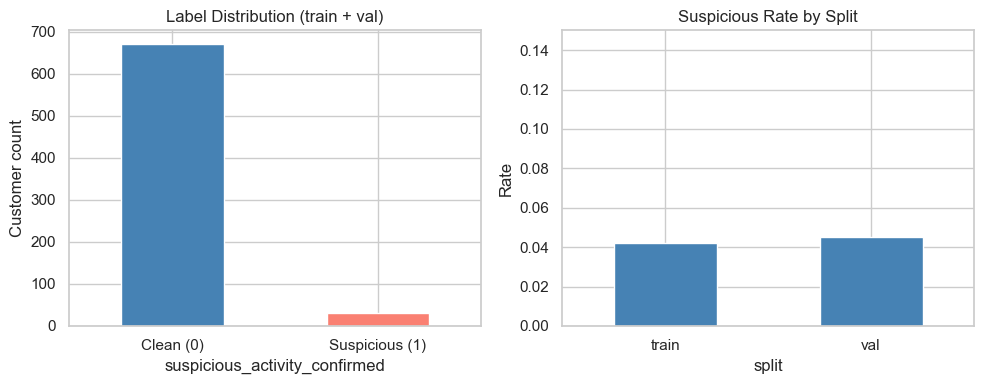

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labeled['suspicious_activity_confirmed'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Label Distribution (train + val)')
axes[0].set_xticklabels(['Clean (0)', 'Suspicious (1)'], rotation=0)
axes[0].set_ylabel('Customer count')

labeled.groupby('split')['suspicious_activity_confirmed'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Suspicious Rate by Split')
axes[1].set_ylabel('Rate')
axes[1].set_ylim(0, 0.15)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**So what?** If the suspicious rate differs substantially between train and val, the split is poorly stratified. 
A consistent ~5% rate across splits is required for reliable evaluation.

---
## 3. Customer Profile Analysis

In [8]:
print(customers['customer_type'].value_counts())
print()
print(labeled.groupby('customer_type')['suspicious_activity_confirmed'].agg(['mean', 'sum', 'count']).round(3))

customer_type
personal       864
sole_trader    147
corporate      100
SME             89
Name: count, dtype: int64

                mean  sum  count
customer_type                   
SME            0.042    2     48
corporate      0.131    8     61
personal       0.026   13    499
sole_trader    0.076    7     92


In [9]:
print('KYC risk rating vs suspicious rate:')
print(labeled.groupby('kyc_risk_rating')['suspicious_activity_confirmed'].agg(['mean', 'sum', 'count']).round(3))

for col in ['pep_status', 'sanctions_screening_flag']:
    print(f'\n{col} vs suspicious rate:')
    print(labeled.groupby(col)['suspicious_activity_confirmed'].agg(['mean', 'sum', 'count']).round(3))

KYC risk rating vs suspicious rate:
                  mean  sum  count
kyc_risk_rating                   
high             0.000    0      5
low              0.043   28    645
medium           0.040    2     50

pep_status vs suspicious rate:
             mean  sum  count
pep_status                   
False       0.043   30    695
True        0.000    0      5

sanctions_screening_flag vs suspicious rate:
                           mean  sum  count
sanctions_screening_flag                   
False                     0.043   30    699
True                      0.000    0      1


In [10]:
labeled2 = customers[customers['suspicious_activity_confirmed'].notna()].copy()
labeled2['suspicious_activity_confirmed'] = labeled2['suspicious_activity_confirmed'].astype(int)
labeled2['nationality_mismatch'] = (labeled2['nationality'] != labeled2['residency_country']).astype(int)

print('Nationality mismatch vs suspicious rate:')
print(labeled2.groupby('nationality_mismatch')['suspicious_activity_confirmed'].agg(['mean', 'sum', 'count']).round(3))

Nationality mismatch vs suspicious rate:
                       mean  sum  count
nationality_mismatch                   
0                     0.045   24    532
1                     0.036    6    168


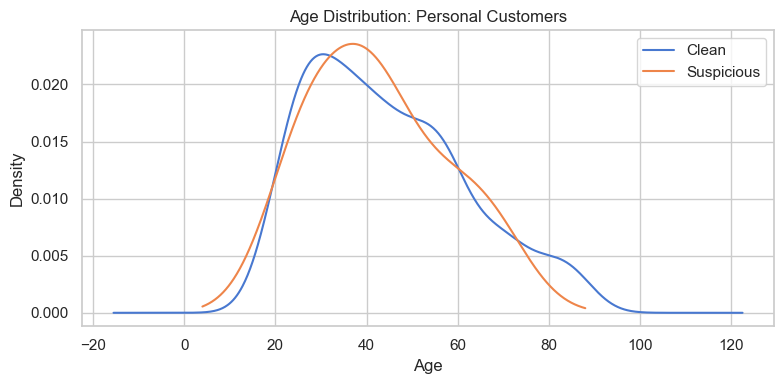

In [11]:
personal = labeled2[labeled2['customer_type'] == 'personal']

fig, ax = plt.subplots(figsize=(8, 4))
for lbl, grp in personal.groupby('suspicious_activity_confirmed'):
    grp['age'].dropna().plot(kind='kde', ax=ax, label='Suspicious' if lbl else 'Clean')
ax.set_title('Age Distribution: Personal Customers')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
occ = labeled2[labeled2['customer_type'] == 'personal'].groupby('occupation_category')['suspicious_activity_confirmed']
print(occ.agg(['mean', 'count']).sort_values('mean', ascending=False).query('count >= 5').round(3))

                      mean  count
occupation_category              
legal                0.091     11
consulting           0.067     15
creative             0.059     17
IT                   0.058     52
self_employed        0.056     18
engineering          0.042     48
finance              0.023     43
management           0.021     48
retired              0.015     65
student              0.015     68
education            0.000     38
healthcare           0.000     43
public_sector        0.000     33


**So what?** KYC, PEP, and sanctions flags are ready-to-use features. Nationality mismatch is a cheap signal. 
If medium-KYC is barely more suspicious than low-KYC, the bank's rating system adds little â€” worth flagging as a finding.

---
## 4. Transaction Behaviour Analysis

In [13]:
print('Transaction types:')
print(transactions['transaction_type'].value_counts())
print('\nChannels:')
print(transactions['channel'].value_counts())
print('\nStatus:')
print(transactions['status'].value_counts())

Transaction types:
transaction_type
transfer              22995
direct_debit          20840
card_payment          15057
standing_order         8264
cash_deposit           4603
cash_withdrawal        3195
international_wire     2430
Name: count, dtype: int64

Channels:
channel
online_banking    57197
mobile_app        12386
branch             4425
ATM                3376
Name: count, dtype: int64

Status:
status
approved    75807
declined     1577
Name: count, dtype: int64


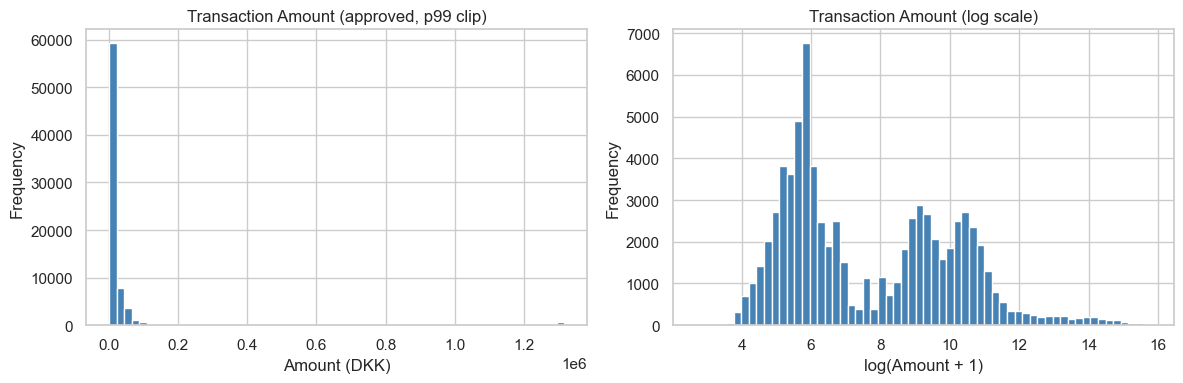

In [14]:
approved = transactions[transactions['status'] == 'approved'].copy()
approved['abs_amount'] = approved['amount'].abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

approved['abs_amount'].clip(upper=approved['abs_amount'].quantile(0.99)).plot(
    kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Amount (approved, p99 clip)')
axes[0].set_xlabel('Amount (DKK)')

approved['abs_amount'].apply(np.log1p).plot(
    kind='hist', bins=60, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Transaction Amount (log scale)')
axes[1].set_xlabel('log(Amount + 1)')
plt.tight_layout()
plt.show()

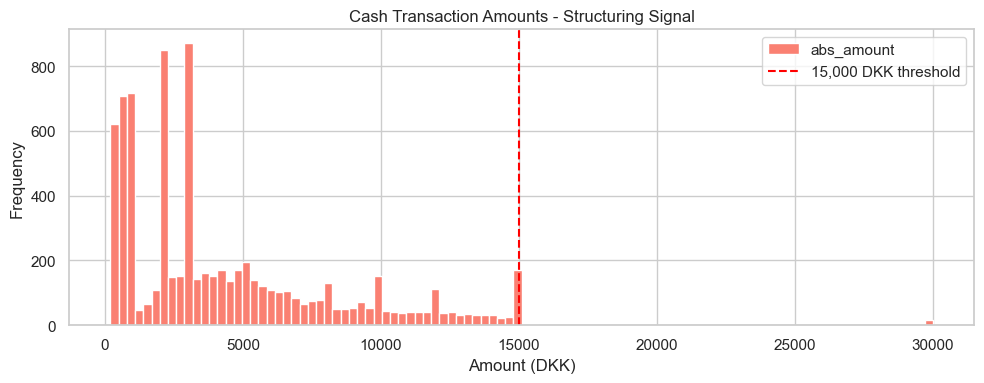

In [15]:
cash_txns = approved[approved['transaction_type'].isin(['cash_deposit', 'cash_withdrawal'])].copy()

fig, ax = plt.subplots(figsize=(10, 4))
cash_txns['abs_amount'].clip(upper=30000).plot(kind='hist', bins=100, ax=ax, color='salmon', edgecolor='white')
ax.axvline(15000, color='red', linestyle='--', label='15,000 DKK threshold')
ax.set_title('Cash Transaction Amounts - Structuring Signal')
ax.set_xlabel('Amount (DKK)')
ax.legend()
plt.tight_layout()
plt.show()

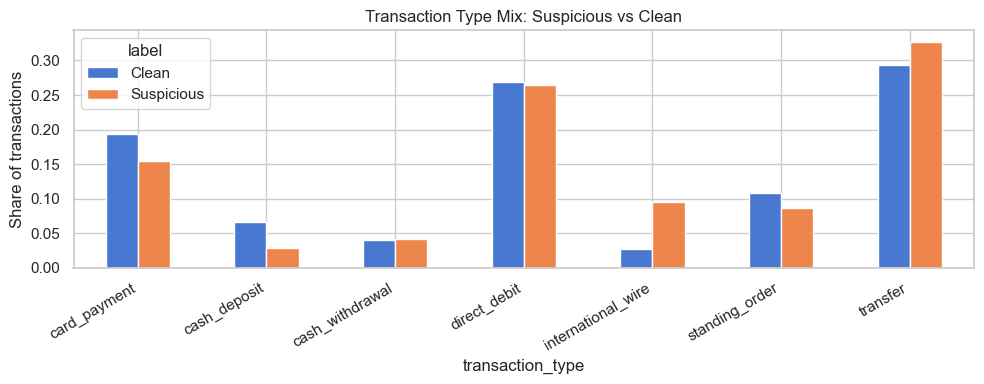

In [16]:
label_map = customers.set_index('customer_id')['suspicious_activity_confirmed']
approved['label'] = approved['customer_id'].map(label_map)
labeled_txns = approved[approved['label'].notna()].copy()
labeled_txns['label'] = labeled_txns['label'].astype(int)

type_mix = (
    labeled_txns.groupby(['label', 'transaction_type'])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum())
    .unstack(level=0)
    .rename(columns={0: 'Clean', 1: 'Suspicious'})
)

type_mix.plot(kind='bar', figsize=(10, 4), edgecolor='white')
plt.title('Transaction Type Mix: Suspicious vs Clean')
plt.ylabel('Share of transactions')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

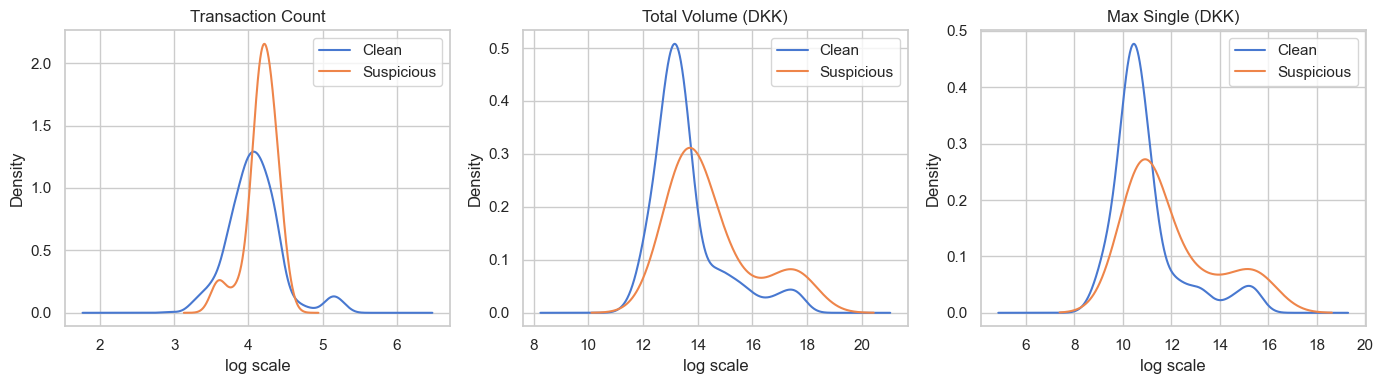

In [17]:
cust_txn_stats = labeled_txns.groupby('customer_id').agg(
    txn_count=('transaction_id', 'count'),
    total_volume=('abs_amount', 'sum'),
    max_single=('abs_amount', 'max'),
).reset_index()
cust_txn_stats['label'] = cust_txn_stats['customer_id'].map(label_map).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
    ['txn_count', 'total_volume', 'max_single'],
    ['Transaction Count', 'Total Volume (DKK)', 'Max Single (DKK)']):
    for lbl, grp in cust_txn_stats.groupby('label'):
        grp[col].apply(np.log1p).plot(kind='kde', ax=ax, label='Suspicious' if lbl else 'Clean')
    ax.set_title(title)
    ax.set_xlabel('log scale')
    ax.legend()
plt.tight_layout()
plt.show()

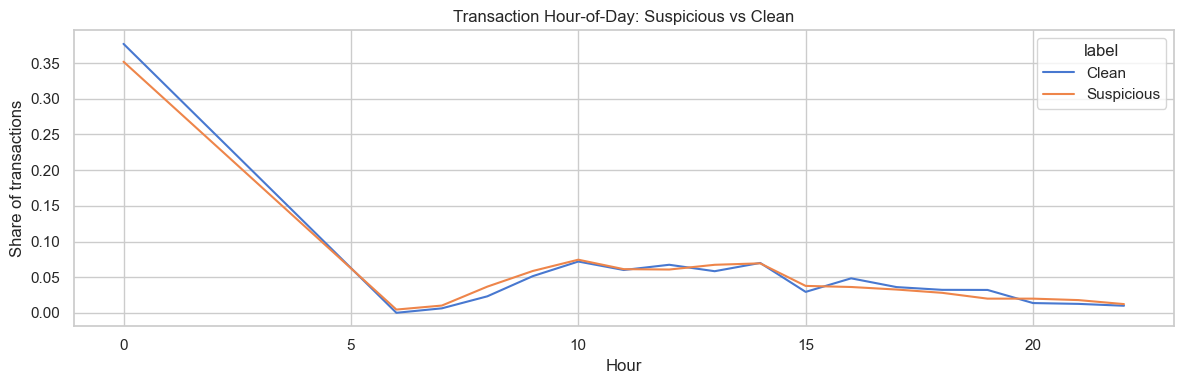

In [18]:
labeled_txns['hour'] = labeled_txns['timestamp'].dt.hour

hour_mix = (
    labeled_txns.groupby(['label', 'hour'])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum())
    .unstack(level=0)
    .rename(columns={0: 'Clean', 1: 'Suspicious'})
)

hour_mix.plot(figsize=(12, 4))
plt.title('Transaction Hour-of-Day: Suspicious vs Clean')
plt.xlabel('Hour')
plt.ylabel('Share of transactions')
plt.tight_layout()
plt.show()

**So what?** A spike just below 15,000 DKK in cash transactions confirms the structuring signal. 
Differences in type mix, volume, and timing identify which raw features are worth aggregating at customer level.

---
## 5. Baseline Feature Distributions

In [19]:
baseline_labeled = baselines.merge(
    customers[['customer_id', 'suspicious_activity_confirmed']], on='customer_id'
).dropna(subset=['suspicious_activity_confirmed'])
baseline_labeled['suspicious_activity_confirmed'] = baseline_labeled['suspicious_activity_confirmed'].astype(int)

baseline_features = [
    'avg_monthly_transaction_count', 'avg_monthly_volume', 'max_single_transaction_6m',
    'pct_international_transactions', 'pct_cash_transactions', 'num_unique_counterparties_6m',
    'transaction_time_entropy', 'geographic_spread_score', 'dormancy_periods_count'
]

print(baseline_labeled.groupby('suspicious_activity_confirmed')[baseline_features].median().T.round(3))

suspicious_activity_confirmed           0           1
avg_monthly_transaction_count       5.000       5.750
avg_monthly_volume              47333.773  140714.368
max_single_transaction_6m       37689.464   67604.751
pct_international_transactions      0.000       0.094
pct_cash_transactions               0.038       0.039
num_unique_counterparties_6m        6.538      11.105
transaction_time_entropy            2.723       2.989
geographic_spread_score             0.000       1.992
dormancy_periods_count              0.000       0.000


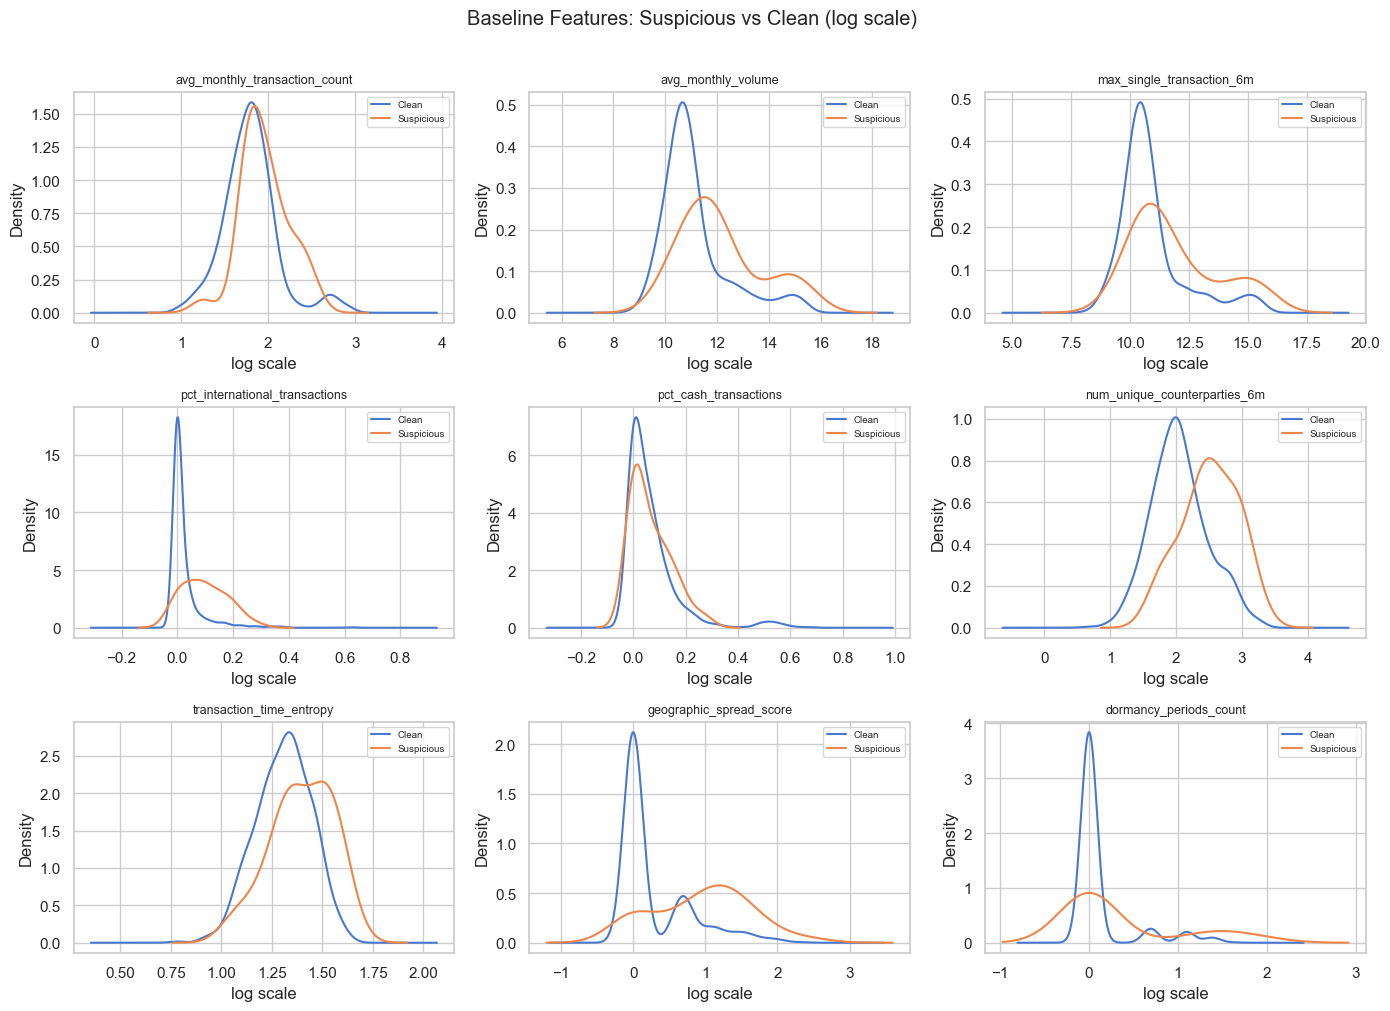

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(baseline_features):
    for lbl, grp in baseline_labeled.groupby('suspicious_activity_confirmed'):
        grp[feat].apply(np.log1p).plot(
            kind='kde', ax=axes[i], label='Suspicious' if lbl else 'Clean')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('log scale')
    axes[i].legend(fontsize=7)

plt.suptitle('Baseline Features: Suspicious vs Clean (log scale)', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
corr = (
    baseline_labeled[baseline_features + ['suspicious_activity_confirmed']]
    .corr()['suspicious_activity_confirmed']
    .drop('suspicious_activity_confirmed')
    .sort_values(key=abs, ascending=False)
)
print('Correlation with label (Pearson):')
print(corr.round(3))

Correlation with label (Pearson):
geographic_spread_score           0.260
num_unique_counterparties_6m      0.227
pct_international_transactions    0.220
dormancy_periods_count            0.182
transaction_time_entropy          0.141
avg_monthly_volume                0.124
max_single_transaction_6m         0.114
avg_monthly_transaction_count     0.082
pct_cash_transactions            -0.005
Name: suspicious_activity_confirmed, dtype: float64


**So what?** Features with large distributional gaps are most discriminative. 
High Pearson correlation = baseline model is viable immediately. 
Low correlation = raw transaction engineering needed to improve signal.

---
## 6. Alert History Analysis

> **Note:** Alert history reflects the old rule-based TMS, not ground-truth labels. For insight only â€” not model features without temporal gating.

In [22]:
alert_counts = alert_history.groupby('customer_id').agg(
    total_alerts=('alert_id', 'count'),
    sar_filed=('analyst_decision', lambda x: (x == 'SAR_filed').sum()),
    escalated=('analyst_decision', lambda x: (x == 'escalated').sum()),
    cleared=('analyst_decision', lambda x: (x == 'cleared').sum()),
).reset_index()

alert_counts['label'] = alert_counts['customer_id'].map(
    customers.set_index('customer_id')['suspicious_activity_confirmed'])
alert_labeled = alert_counts.dropna(subset=['label']).copy()
alert_labeled['label'] = alert_labeled['label'].astype(int)

print(alert_labeled.groupby('label')[['total_alerts', 'sar_filed', 'escalated', 'cleared']].median().round(1))

       total_alerts  sar_filed  escalated  cleared
label                                             
0              16.0        2.0        3.0      8.0
1              14.0        2.0        3.0      8.0


In [23]:
rule_label = alert_history.merge(
    customers[['customer_id', 'suspicious_activity_confirmed']], on='customer_id'
).dropna(subset=['suspicious_activity_confirmed'])
rule_label['suspicious_activity_confirmed'] = rule_label['suspicious_activity_confirmed'].astype(int)

rule_summary = (
    rule_label.groupby('trigger_rule')['suspicious_activity_confirmed']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .round(3)
)
print('Suspicious rate by trigger rule:')
print(rule_summary)

Suspicious rate by trigger rule:
                     mean  count
trigger_rule                    
threshold           0.055   3191
geographic_risk     0.045   1432
rapid_movement      0.042   2983
large_cash          0.015   1377
structuring         0.007   1344
dormant_activation  0.005    933


In [24]:
fp_by_rule = (
    alert_history.groupby('trigger_rule')
    .apply(lambda x: (x['analyst_decision'] == 'cleared').mean())
    .sort_values(ascending=False)
    .round(3)
)
print('Analyst clear rate (proxy for FP rate) by rule:')
print(fp_by_rule)

Analyst clear rate (proxy for FP rate) by rule:
trigger_rule
dormant_activation    0.575
large_cash            0.562
rapid_movement        0.554
threshold             0.552
geographic_risk       0.551
structuring           0.550
dtype: float64


C:\Users\kubad\AppData\Local\Temp\ipykernel_24000\945719938.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['analyst_decision'] == 'cleared').mean())


In [25]:
alerted = set(alert_history['customer_id'])
no_alert = customers[~customers['customer_id'].isin(alerted)]
no_alert_lab = no_alert.dropna(subset=['suspicious_activity_confirmed'])
print(f'Customers with no TMS alerts: {len(no_alert)}')
print(f"Confirmed suspicious among them: {no_alert_lab['suspicious_activity_confirmed'].sum():.0f}")
print(f"Suspicious rate: {no_alert_lab['suspicious_activity_confirmed'].mean():.1%}")

Customers with no TMS alerts: 5
Confirmed suspicious among them: 0
Suspicious rate: 0.0%


**So what?** Rules with the highest clear rates are the biggest FP contributors â€” our model must beat these specifically. 
Suspicious customers never alerted by TMS are blind spots â€” catching them improves recall. 
The gap between TMS performance and confirmed labels defines the improvement ceiling.

---
## 7. Accounts Analysis

In [26]:
print(accounts['account_type'].value_counts())
print(f"Currencies: {accounts['currency'].unique()}")

account_type
current             1011
savings              919
business             431
foreign_currency     341
Name: count, dtype: int64
Currencies: ['DKK' 'EUR' 'GBP' 'USD' 'SEK']


In [27]:
accounts['is_dormant'] = (
    (accounts['avg_monthly_balance_6m'] == 0) &
    (accounts['avg_monthly_inflow_6m'] == 0) &
    (accounts['avg_monthly_outflow_6m'] == 0)
).astype(int)

acc_agg = accounts.groupby('customer_id').agg(
    num_accounts=('account_id', 'count'),
    num_dormant=('is_dormant', 'sum'),
    has_foreign_currency=('currency', lambda x: int((x != 'DKK').any())),
    total_balance=('avg_monthly_balance_6m', 'sum'),
    total_inflow=('avg_monthly_inflow_6m', 'sum'),
    total_outflow=('avg_monthly_outflow_6m', 'sum'),
).reset_index()

acc_agg['label'] = acc_agg['customer_id'].map(
    customers.set_index('customer_id')['suspicious_activity_confirmed'])
acc_labeled = acc_agg.dropna(subset=['label']).copy()
acc_labeled['label'] = acc_labeled['label'].astype(int)

print(acc_labeled.groupby('label')[['num_accounts', 'num_dormant', 'total_balance', 'total_inflow', 'total_outflow']].median().round(1))

       num_accounts  num_dormant  total_balance  total_inflow  total_outflow
label                                                                       
0               2.0          1.0        70081.5       38537.1         8372.4
1               3.0          2.0       130247.0       94390.4        19459.9


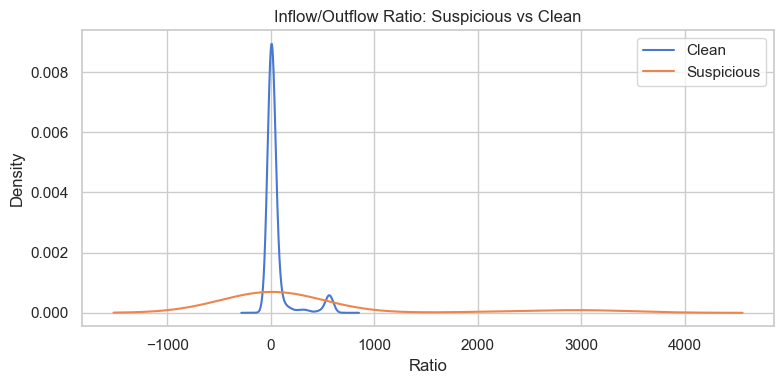

In [28]:
acc_labeled['inflow_outflow_ratio'] = acc_labeled['total_inflow'] / (acc_labeled['total_outflow'] + 1)

fig, ax = plt.subplots(figsize=(8, 4))
for lbl, grp in acc_labeled.groupby('label'):
    grp['inflow_outflow_ratio'].clip(upper=grp['inflow_outflow_ratio'].quantile(0.95)).plot(
        kind='kde', ax=ax, label='Suspicious' if lbl else 'Clean')
ax.set_title('Inflow/Outflow Ratio: Suspicious vs Clean')
ax.set_xlabel('Ratio')
ax.legend()
plt.tight_layout()
plt.show()

**So what?** Dormant accounts that activate are a known AML red flag. 
Many accounts with low balance can indicate structuring across accounts. 
High inflow/outflow ratio signals layering â€” funds cycling in without clear economic outflow.

---
## 8. Country Risk Analysis

In [29]:
print(country_risk.shape)
print(country_risk.head(10))
print(f"EU high-risk: {country_risk[country_risk['eu_high_risk_list']]['country_code'].tolist()}")
print(f"Non-compliant FATF: {country_risk[country_risk['fatf_status'] != 'compliant']['country_code'].tolist()}")

(48, 4)
  country_code fatf_status  corruption_perception_index  eu_high_risk_list
0           DK   compliant                           88              False
1           SE   compliant                           83              False
2           NO   compliant                           84              False
3           FI   compliant                           87              False
4           IS   compliant                           74              False
5           DE   compliant                           79              False
6           GB   compliant                           71              False
7           NL   compliant                           79              False
8           FR   compliant                           71              False
9           CH   compliant                           82              False
EU high-risk: ['TR', 'PK', 'NG', 'IR', 'KP', 'MM', 'SY', 'AF']
Non-compliant FATF: ['RO', 'BG', 'AE', 'TR', 'PH', 'VN', 'PK', 'NG', 'KE', 'ZA', 'TZ', 'IR', 'KP', 'MM',

In [30]:
intl_txns = transactions[transactions['counterparty_bank_country'].notna()].copy()
print(f'International transactions: {len(intl_txns):,} ({len(intl_txns)/len(transactions):.1%} of total)')
print('\nTop counterparty countries:')
print(intl_txns['counterparty_bank_country'].value_counts().head(15))

International transactions: 2,570 (3.3% of total)

Top counterparty countries:
counterparty_bank_country
AE    377
TR    317
PH    226
VN    179
PK    178
NO    128
NL    128
US    125
DE    124
CN    119
SE    119
GB    114
IN     79
NG     60
CZ     22
Name: count, dtype: int64


In [31]:
intl_txns = intl_txns.merge(country_risk, left_on='counterparty_bank_country', right_on='country_code', how='left')
intl_txns['label'] = intl_txns['customer_id'].map(
    customers.set_index('customer_id')['suspicious_activity_confirmed'])
intl_labeled = intl_txns[intl_txns['label'].notna()].copy()
intl_labeled['label'] = intl_labeled['label'].astype(int)

print('Share of txns to EU high-risk countries by label:')
print(intl_labeled.groupby('label')['eu_high_risk_list'].mean().round(3))
print('\nAvg CPI of counterparty country by label:')
print(intl_labeled.groupby('label')['corruption_perception_index'].mean().round(1))

Share of txns to EU high-risk countries by label:
label
0    0.263
1    0.175
Name: eu_high_risk_list, dtype: float64

Avg CPI of counterparty country by label:
label
0    52.6
1    54.6
Name: corruption_perception_index, dtype: float64


In [32]:
cust_risk = customers.merge(country_risk, left_on='nationality', right_on='country_code', how='left')
cust_risk_lab = cust_risk[cust_risk['suspicious_activity_confirmed'].notna()].copy()
cust_risk_lab['suspicious_activity_confirmed'] = cust_risk_lab['suspicious_activity_confirmed'].astype(int)

print('Suspicious rate by FATF status of customer nationality:')
print(cust_risk_lab.groupby('fatf_status')['suspicious_activity_confirmed'].agg(['mean', 'count']).round(3))
print('\nMedian CPI by label:')
print(cust_risk_lab.groupby('suspicious_activity_confirmed')['corruption_perception_index'].median().round(1))

Suspicious rate by FATF status of customer nationality:
                      mean  count
fatf_status                      
compliant            0.045    667
enhanced_monitoring  0.000     33

Median CPI by label:
suspicious_activity_confirmed
0    88.0
1    88.0
Name: corruption_perception_index, dtype: float64


**So what?** International exposure to high-risk jurisdictions is a direct AML signal. 
Engineer: share of transactions to EU high-risk countries, minimum CPI across counterparties, 
EU high-risk flag on customer nationality.

---
## 9. EDA Summary

### Modeling workflow clarification

- **Our development loop:** train split (500 customers, 21 suspicious) to fit; val split (200 customers, 9 suspicious) to evaluate.
- **Organiser test set:** 500 customers with null labels held out by the organisers. We generate  for these only at the end, after retraining on train+val combined.
- Do not conflate the two — the test set plays no role in model development.

### TMS performance (corrected)

- The Case Brief states the existing TMS flags ~15,000 **transactions** per month with a **97% false positive rate** at the transaction level.
- Our sample data shows analyst clear rates of ~55% across all rules — this reflects **customer-level** alert resolution, not transaction-level. These are different denominators.
- The 97% figure (Case Brief) is the headline business problem. The 55% clear rate in our data is the signal we can directly model against.

### Key findings by section

| # | Finding | What the data shows | Feature implication |
|---|---|---|---|
| 1 | Join integrity | No orphan IDs; 5 customers have no alert history (all clean) | No data quality blockers |
| 2 | Class imbalance | 4.3% suspicious (30/700 labeled); train 4.2%, val 4.5% — well stratified | Use PR-AUC not accuracy; stratified split is valid |
| 3 | Customer type | Corporate 13.1% suspicious, sole_trader 7.6%, personal 2.6% | Encode customer type; corporate is highest-risk segment |
| 3 | KYC rating | medium-KYC (4.0%) barely differs from low-KYC (4.3%); high-KYC has 0 suspicious | KYC rating adds almost no signal — flag this as a finding |
| 3 | PEP & sanctions | 0 suspicious among PEP or sanctions-flagged customers | Flags add no predictive signal in this dataset |
| 3 | Nationality mismatch | Mismatch rate 3.6% suspicious vs 4.5% for match — slightly *lower* | Mismatch is not a positive signal here; exclude or use cautiously |
| 3 | Occupation | Legal (9.1%), consulting (6.7%), creative (5.9%), IT (5.8%) highest; healthcare/education/public sector 0% | Encode occupation risk; high variance across categories |
| 4 | Transaction types | Transfers (30%), direct debits (27%), card payments (19%) dominate; international wires only 3.1% | Focus feature engineering on transfer and cash types |
| 4 | Structuring | Cash txns cluster below 15,000 DKK threshold confirmed visually | Engineer structuring band count [13k-15k] |
| 5 | Strongest baseline signals | geographic_spread_score (r=0.26), num_unique_counterparties (r=0.23), pct_international (r=0.22), dormancy_periods (r=0.18) | These four are the most discriminative pre-computed features |
| 5 | Weakest baseline signal | pct_cash_transactions (r=-0.005) — essentially zero correlation | Cash share alone is not predictive; directionality and structuring pattern matter more |
| 5 | Volume difference | Suspicious median monthly volume 140k DKK vs 47k DKK clean — 3x higher | Volume is a signal but overlaps heavily; use in combination |
| 6 | Alert history | Median alert counts nearly identical: suspicious 14 vs clean 16 — TMS does not separate them | Alert count is a weak feature; rule type matters more than count |
| 6 | Best TMS rule | threshold (5.5% suspicious rate); worst: dormant_activation (0.5%) and structuring (0.7%) | Structuring rule is paradoxically the worst predictor of confirmed suspicious |
| 6 | TMS blind spots | Only 5 customers had no alerts, all clean — TMS has near-complete coverage but poor precision | Problem is FP rate, not missed coverage |
| 7 | Accounts | Suspicious: median 3 accounts, 2 dormant vs clean: 2 accounts, 1 dormant | num_accounts and num_dormant are useful features |
| 7 | Balance & flows | Suspicious median balance 130k vs 70k clean; inflow 94k vs 39k | Higher absolute flows for suspicious — consistent with volume finding |
| 8 | Country risk | Counterintuitive: clean customers show *higher* EU high-risk country share (26% vs 18%) and lower avg CPI | Country risk via counterparty transactions is not a clean signal here |
| 8 | Nationality CPI | Median CPI identical (88) for both labels — nationality risk adds no signal | Drop nationality-based country risk features; focus on geographic_spread_score instead |
| 8 | High-risk countries | AE, TR, PH, VN, PK are the top international counterparty destinations | These are worth encoding individually if volume justifies it |

### Surprises worth flagging

- **KYC, PEP, sanctions add no signal** — the bank's own risk classification is not predictive of confirmed suspicious activity.
- **Nationality mismatch goes the wrong way** — customers with matching nationality/residency are slightly *more* suspicious.
- **Country risk via transactions is noisy** — clean customers have more EU high-risk country exposure than suspicious ones in this sample.
- **TMS structuring rule is the worst predictor** (0.7% suspicious rate) despite structuring being the most famous AML pattern — the rule may be miscalibrated.
- **The core signal is geographic spread + counterparty diversity + volume**, not the static flags the bank relies on.
